# Churn: priorizar retenção sem vazamento

> **Dados integralmente sintéticos.** Execute `python -m src.pipeline` antes deste notebook.

A população elegível transacionou nos 30 dias anteriores a 30/11/2025. Churn significa nenhuma transação nos 30 dias seguintes, sem supor encerramento definitivo da conta.

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
if not (root / "src").exists():
    root = root.parent
sys.path.insert(0, str(root))
import pandas as pd
from IPython.display import display, Image
from src.config import DATA, REPORTS, FIGURES


## Features históricas e rótulo futuro

In [2]:
from src.churn import build_features, run
accounts = pd.read_parquet(DATA / 'accounts.parquet')
transactions = pd.read_parquet(DATA / 'transactions.parquet')
frame = build_features(accounts, transactions)
display(frame.head())
display(run(accounts, transactions))

C:\Users\jvbrg\Documents\Codex\2026-09-18\crie-do-zero-o-projeto-digital-4\work\clean-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,opened_at,segment,count_recent,count_previous,activity_ratio,recency,mean_amount,tenure,churn
account_id,,,,,,,,,
1,2024-08-20,essencial,33,38,0.871795,2,66.117576,467,0
2,2024-07-15,essencial,11,19,0.600000,3,69.881818,503,0
3,2024-05-11,premium,19,5,3.333333,2,150.445789,568,0
6,2024-01-26,essencial,25,23,1.083333,0,90.554800,674,0
7,2024-07-28,premium,40,45,0.891304,0,86.903500,490,0


{'models': [{'model': 'Regressão logística',
   'cv_auc_mean': 0.9850096036768363,
   'cv_auc_std': 0.008816600186336865,
   'test_auc': 0.9966666666666666,
   'ks': 0.9563636363636364,
   'brier': 0.008687519599811148},
  {'model': 'LightGBM',
   'cv_auc_mean': 0.981085901459416,
   'cv_auc_std': 0.011828578114245482,
   'test_auc': 0.9952651515151514,
   'ks': 0.9551515151515152,
   'brier': 0.009602024014518776}],
 'selected_model': 'Regressão logística',
 'eligible_accounts': 3428,
 'test_accounts': 857,
 'test_churn_rate': 0.03733955659276546,
 'targeted_accounts': 32,
 'target_precision': 0.84375,
 'target_recall': 0.84375,
 'true_positive_targets': 27}

## Desempenho e calibração no teste reservado

,model,cv_auc_mean,cv_auc_std,test_auc,ks,brier
0,Regressão logística,0.985010,0.008817,0.996667,0.956364,0.008688
1,LightGBM,0.981086,0.011829,0.995265,0.955152,0.009602


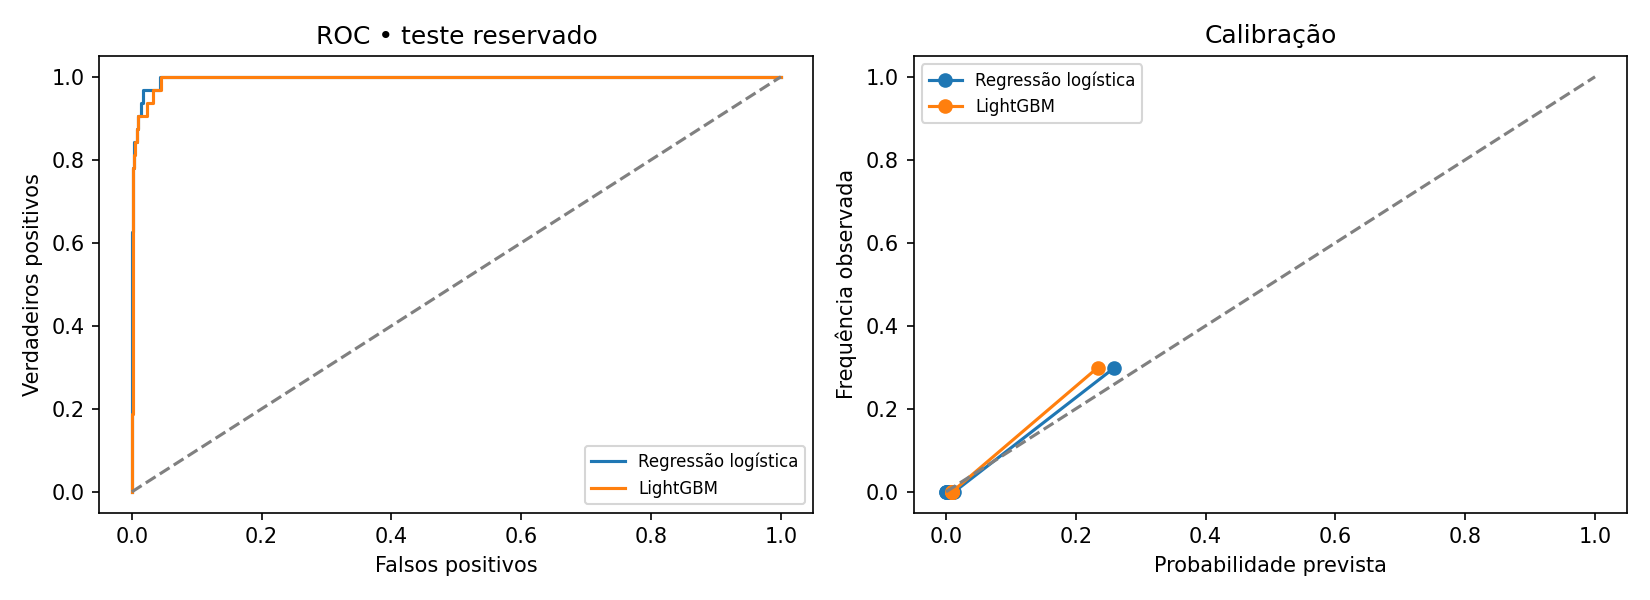

In [3]:
display(pd.read_csv(REPORTS / 'churn_metrics.csv'))
display(Image(filename=str(FIGURES / 'churn_evaluation.png')))

## Interpretabilidade global e local

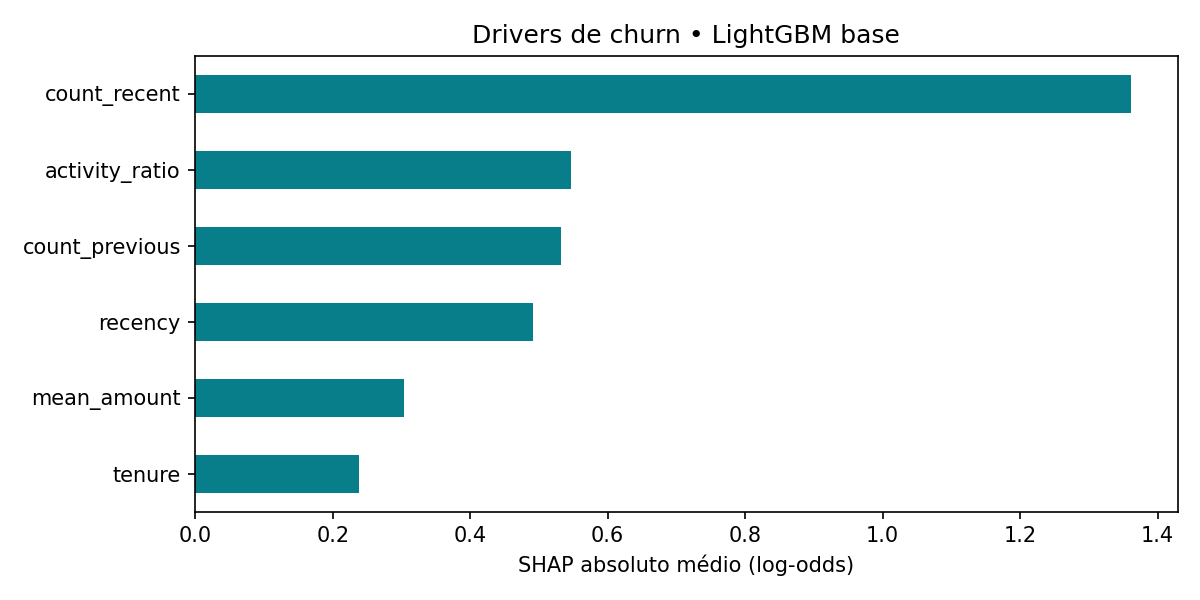

,account_id,count_recent,count_previous,activity_ratio,recency,mean_amount,tenure,churn,churn_probability,count_recent_shap,count_previous_shap,activity_ratio_shap,recency_shap,mean_amount_shap,tenure_shap
0,4815,1,9,0.200000,29,51.05,610,1,0.989434,4.001512,0.391137,2.476015,6.287697,-0.340822,-0.115707
1,4057,1,17,0.111111,25,67.10,540,1,0.981597,4.197709,-0.009162,1.844308,6.820276,0.116423,0.210038
2,860,2,13,0.214286,25,97.91,409,1,0.970311,4.284910,-0.107593,2.353944,6.241097,-0.169013,0.058525
3,2379,3,11,0.333333,24,151.79,503,1,0.965547,4.279461,0.011316,1.943114,5.844059,1.260503,0.045038
4,815,1,5,0.333333,24,141.46,448,1,0.964712,4.255388,0.227347,2.113021,6.166891,0.996933,-0.308881


In [4]:
display(Image(filename=str(FIGURES / 'shap.png')))
probabilities = pd.read_csv(REPORTS / 'churn_predictions.csv')
local = pd.read_csv(REPORTS / 'shap_local.csv')
display(probabilities.nlargest(5, 'churn_probability').merge(local, on='account_id', suffixes=('', '_shap')))

## Leitura crítica

Uma linha por conta: 75% desenvolvimento, 25% teste estratificado. CV externa com cinco folds mede modelos calibrados; cada fold ajusta calibração sigmoide em três folds internos. Modelo escolhido pela AUC de CV, nunca pelo teste. KS mede separação das distribuições, Brier mede erro probabilístico. SHAP explica a árvore LightGBM base em log-odds, não a probabilidade calibrada nem necessariamente o modelo vencedor. Esta validação em um único corte não mede generalização temporal; produção exigiria cortes posteriores e teste de drift.